# User State-Aware Early Exiting for Real-Time Text Autocomplete on Edge Keyboards

**Base method:** CALM — Confident Adaptive Language Modeling (Schuster et al., NeurIPS 2022)
**Dataset:** TinyStories (Eldan & Li, 2023) — short children's stories, informal sentence structure
**Extension 1:** AUEP composite confidence — four signals (confidence + entropy + margin + consistency) with learned weights
**Extension 2:** Struggle-aware dynamic threshold — adjusts exit policy from user interaction signals

### Run order
Run cells top to bottom without skipping any cell.
All cells depend on the ones above them.

> **Why TinyStories?** Short, grammatically simple sentences with common vocabulary —
> much closer to real keyboard/autocomplete text than encyclopedic Wikipedia prose.
> We use the GPT4-curated validation split (~22MB) to keep training fast on Kaggle.
> The training split (~2GB) would give better results but takes much longer to download.
> For a paper submission, state clearly which split was used.

### Important settings
- GPU: must be ON (Settings → Accelerator → GPU T4)
- Internet: must be ON (Settings → Internet → On)


## 1. Environment Setup

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "torch", "--quiet"], check=False)

import os, re, json, math, random
from pathlib import Path
from collections import Counter, deque
from dataclasses import dataclass, field
from typing import List, Optional, Dict, Tuple
from statistics import mean

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import urllib.request
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 4)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

# ── paths (Kaggle-friendly) ────────────────────────────────────────────
BASE_DIR   = Path("/kaggle/working")
CKPT_DIR   = BASE_DIR / "checkpoints"
DATA_DIR   = BASE_DIR / "data"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# ── hyper-parameters (good defaults for Kaggle T4 GPU) ────────────────
CFG = dict(
    d_model      = 384,     # was 256 -> wider representations
    n_layer      = 8,       # was 6 -> more depth, more useful early-exit points
    n_head       = 8,
    d_ff         = 1536,    # was 1024 -> kept at 4x d_model
    max_len      = 28,
    vocab_size   = 12000,   # was 8000 -> fewer <unk> tokens, sharper softmax mass
    batch_size   = 96,      # was 64 -> nudge up now that we have more data
    lr           = 1e-3,
    ssl_epochs   = 60,      # was 40 -> more pretraining passes
    exit_epochs  = 30,      # was 20 -> more time for exit classifier to converge
    max_lines    = 20000,   # was 10000 -> more TinyStories sentences to support the bigger vocab/model
)
print("Config:", CFG)


Device: cuda
PyTorch: 2.10.0+cu128
Config: {'d_model': 384, 'n_layer': 8, 'n_head': 8, 'd_ff': 1536, 'max_len': 28, 'vocab_size': 12000, 'batch_size': 96, 'lr': 0.001, 'ssl_epochs': 60, 'exit_epochs': 30, 'max_lines': 20000}


## 2. Data Utilities

In [2]:
PAD, BOS, EOS, UNK = "<pad>", "<bos>", "<eos>", "<unk>"
SPECIAL_TOKENS = [PAD, BOS, EOS, UNK]
_WORD_RE = re.compile(r"[a-z0-9']+|[.,!?;]")

def simple_tokenize(text): return _WORD_RE.findall(text.lower())

class WordTokenizer:
    def __init__(self, vocab):
        self.vocab  = vocab
        self.tok2id = {t: i for i, t in enumerate(vocab)}
        self.id2tok = {i: t for i, t in enumerate(vocab)}
        self.pad_id = self.tok2id[PAD]; self.bos_id = self.tok2id[BOS]
        self.eos_id = self.tok2id[EOS]; self.unk_id = self.tok2id[UNK]

    @classmethod
    def build(cls, texts, max_vocab_size=8000):
        cnt = Counter()
        for l in texts: cnt.update(simple_tokenize(l))
        top = [w for w, _ in cnt.most_common(max_vocab_size)]
        return cls(SPECIAL_TOKENS + top)

    def encode(self, text, add_special=True):
        ids = [self.tok2id.get(t, self.unk_id) for t in simple_tokenize(text)]
        return ([self.bos_id] + ids + [self.eos_id]) if add_special else ids

    def decode(self, ids):
        skip = {self.pad_id, self.bos_id, self.eos_id}
        return " ".join(self.id2tok.get(i, UNK) for i in ids if i not in skip)

    def save(self, p): Path(p).write_text(json.dumps(self.vocab), encoding="utf-8")

    @classmethod
    def load(cls, p): return cls(json.loads(Path(p).read_text(encoding="utf-8")))

    def __len__(self): return len(self.vocab)


class AutocompleteDataset(Dataset):
    def __init__(self, lines, tokenizer, max_len=32):
        self.examples = []
        self.pad_id = tokenizer.pad_id
        for l in lines:
            if l.strip():
                self.examples.append(tokenizer.encode(l.strip())[:max_len])

    def __len__(self): return len(self.examples)
    def __getitem__(self, i): return self.examples[i]


def collate_batch(batch, pad_id):
    T = max(len(x) for x in batch)
    ids  = torch.full((len(batch), T), pad_id, dtype=torch.long)
    mask = torch.zeros((len(batch), T), dtype=torch.bool)
    for i, x in enumerate(batch):
        ids[i, :len(x)] = torch.tensor(x); mask[i, :len(x)] = True
    return ids, mask

print("Data utilities defined ✓")


Data utilities defined ✓


## 3. Model — TinyGPT (CALM Causal Decoder)

In [3]:
@dataclass
class TinyGPTConfig:
    vocab_size: int
    d_model: int = 256; n_layer: int = 6; n_head: int = 8
    d_ff: int = 1024;   max_seq_len: int = 64; dropout: float = 0.1


class CausalSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.n_head = cfg.n_head
        self.d_head = cfg.d_model // cfg.n_head
        self.q_proj = nn.Linear(cfg.d_model, cfg.d_model)
        self.k_proj = nn.Linear(cfg.d_model, cfg.d_model)
        self.v_proj = nn.Linear(cfg.d_model, cfg.d_model)
        self.out_proj = nn.Linear(cfg.d_model, cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)

    def _split(self, x):
        B, T, D = x.shape
        return x.view(B, T, self.n_head, self.d_head).transpose(1, 2)

    def project_kv(self, x):
        return self._split(self.k_proj(x)), self._split(self.v_proj(x))

    def forward_seq(self, x, mask):
        B, T, D = x.shape
        q = self._split(self.q_proj(x)); k, v = self.project_kv(x)
        att = (q @ k.transpose(-2, -1)) / (self.d_head ** 0.5)
        att = att.masked_fill(mask[:, :, :T, :T] == 0, float("-inf"))
        out = (self.drop(F.softmax(att, -1)) @ v).transpose(1, 2).reshape(B, T, D)
        return self.out_proj(out)

    def step(self, x_t, kc, vc):
        q = self._split(self.q_proj(x_t)); kn, vn = self.project_kv(x_t)
        ka = kn if kc is None else torch.cat([kc, kn], 2)
        va = vn if vc is None else torch.cat([vc, vn], 2)
        att = F.softmax((q @ ka.transpose(-2, -1)) / (self.d_head ** 0.5), -1)
        out = (att @ va).transpose(1, 2).reshape(x_t.shape[0], 1, -1)
        return self.out_proj(out), ka, va

    def kv_from_copy(self, h, ln, kc, vc):
        kn, vn = self.project_kv(ln(h))
        ka = kn if kc is None else torch.cat([kc, kn], 2)
        va = vn if vc is None else torch.cat([vc, vn], 2)
        return ka, va


class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc1 = nn.Linear(cfg.d_model, cfg.d_ff)
        self.fc2 = nn.Linear(cfg.d_ff, cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)
    def forward(self, x): return self.fc2(self.drop(F.gelu(self.fc1(x))))


class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.d_model)
        self.attn = CausalSelfAttention(cfg)
        self.ln2 = nn.LayerNorm(cfg.d_model)
        self.mlp = MLP(cfg)
        self.drop = nn.Dropout(cfg.dropout)

    def forward_seq(self, x, mask):
        x = x + self.drop(self.attn.forward_seq(self.ln1(x), mask))
        return x + self.drop(self.mlp(self.ln2(x)))

    def step(self, x_t, kc, vc):
        a, kc, vc = self.attn.step(self.ln1(x_t), kc, vc)
        x_t = x_t + self.drop(a)
        return x_t + self.drop(self.mlp(self.ln2(x_t))), kc, vc

    def kv_from_copy(self, h, kc, vc):
        return self.attn.kv_from_copy(h, self.ln1, kc, vc)


class TinyGPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.tok_emb  = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos_emb  = nn.Embedding(cfg.max_seq_len, cfg.d_model)
        self.drop     = nn.Dropout(cfg.dropout)
        self.blocks   = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)])
        self.ln_f     = nn.LayerNorm(cfg.d_model)
        self.lm_head  = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.lm_head.weight = self.tok_emb.weight   # tied weights (CALM)
        self.exit_cls = nn.ModuleList(               # per-layer exit probes
            [nn.Linear(cfg.d_model, 1) for _ in range(cfg.n_layer - 1)])
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(cfg.max_seq_len, cfg.max_seq_len))
                  .view(1, 1, cfg.max_seq_len, cfg.max_seq_len))
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0, 0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, 0, 0.02)

    def forward_all_layers(self, ids):
        B, T = ids.shape
        # FIX: guard sequence length so pos_emb never goes out of bounds
        assert T <= self.cfg.max_seq_len, (
            f"Sequence length {T} > max_seq_len {self.cfg.max_seq_len}. "
            "Increase max_seq_len in CFG or truncate inputs.")
        pos = torch.arange(T, device=ids.device).unsqueeze(0)
        x = self.drop(self.tok_emb(ids) + self.pos_emb(pos))
        hs, ls = [], []
        for blk in self.blocks:
            x = blk.forward_seq(x, self.causal_mask)
            hs.append(x); ls.append(self.lm_head(self.ln_f(x)))
        return hs, ls

    def forward_full(self, ids):
        return self.forward_all_layers(ids)[1][-1]

    def init_kv(self):
        return [None] * self.cfg.n_layer, [None] * self.cfg.n_layer

    @torch.no_grad()
    def decode_step(self, tok, pos, kc, vc, conf_fn, thresh_fn):
        # FIX: clip position to valid range
        pos = min(pos, self.cfg.max_seq_len - 1)
        pos_t = torch.tensor([[pos]], device=tok.device)
        x = self.tok_emb(tok) + self.pos_emb(pos_t)
        h_prev = x
        exit_l, logits_out = self.cfg.n_layer, None
        prev_preds = []

        for i, blk in enumerate(self.blocks, 1):
            x, kc[i-1], vc[i-1] = blk.step(x, kc[i-1], vc[i-1])
            li = self.lm_head(self.ln_f(x))
            prev_preds.append(li.argmax(-1))

            if i < self.cfg.n_layer:
                c = conf_fn(layer_idx=i, hidden_i=x, hidden_im1=h_prev,
                            logits_i=li, model=self, prev_predictions=prev_preds)
                if c >= thresh_fn(layer_idx=i, position=pos):
                    exit_l, logits_out = i, li
                    break
            h_prev = x

        if logits_out is None:
            logits_out = li
        # state propagation: fill K/V for all skipped layers
        if exit_l < self.cfg.n_layer:
            for j in range(exit_l, self.cfg.n_layer):
                kc[j], vc[j] = self.blocks[j].kv_from_copy(x, kc[j], vc[j])
        return logits_out, exit_l, kc, vc

    def num_params(self):
        return sum(p.numel() for p in self.parameters())

print("TinyGPT defined ✓")


TinyGPT defined ✓


## 4. Composite Confidence — AUEP Four Signals

The four signals from AUEP adapted for CALM's causal decoder, combined into
one scalar that LTT calibration can threshold statistically.

| Signal | Formula | High = ? |
|---|---|---|
| confidence | max softmax prob | Confident |
| entropy | normalized Shannon entropy | Low = confident |
| margin | top1 − top2 probability | Confident |
| consistency | fraction of earlier layers agreeing with current | Consistent |


In [4]:
def _conf(logits):
    return F.softmax(logits, dim=-1).max(dim=-1).values.item()

def _entropy(logits):
    p = F.softmax(logits, dim=-1)
    h = -(p * torch.log(p + 1e-12)).sum(-1)
    return (h / math.log(logits.shape[-1])).item()

def _margin(logits):
    p = F.softmax(logits, dim=-1).topk(2,-1).values
    return (p[...,0] - p[...,1]).item()

def _consistency(logits, prev_preds):
    if not prev_preds: return 1.0
    cur = logits.argmax(-1)
    return sum(1 for p in prev_preds if p.item() == cur.item()) / len(prev_preds)


# ── learned weights (updated by Stage 2b below) ────────────────────────
COMPOSITE_WEIGHTS = {"confidence": 0.35, "entropy": 0.25,
                     "margin": 0.20, "consistency": 0.20}

def composite_confidence(layer_idx, hidden_i, hidden_im1, logits_i,
                         model, prev_predictions=None, **kwargs):
    w  = COMPOSITE_WEIGHTS
    pp = prev_predictions or []
    lf = logits_i.reshape(-1, logits_i.shape[-1])[0].unsqueeze(0)
    c  = _conf(lf); e = _entropy(lf); m = _margin(lf)
    k  = _consistency(lf, pp)
    score = w["confidence"]*c + w["entropy"]*(1-e) + w["margin"]*m + w["consistency"]*k
    return torch.tensor(score, device=logits_i.device)

def signal_breakdown(logits_i, prev_preds=None):
    pp = prev_preds or []
    lf = logits_i.reshape(-1, logits_i.shape[-1])[0].unsqueeze(0)
    c  = _conf(lf); e = _entropy(lf); m = _margin(lf); k = _consistency(lf, pp)
    w  = COMPOSITE_WEIGHTS
    return {"confidence": round(c,4), "entropy": round(e,4),
            "margin": round(m,4),     "consistency": round(k,4),
            "composite": round(w["confidence"]*c + w["entropy"]*(1-e) +
                               w["margin"]*m + w["consistency"]*k, 4)}

print("Composite confidence defined ✓")
print("Default weights:", COMPOSITE_WEIGHTS)


Composite confidence defined ✓
Default weights: {'confidence': 0.35, 'entropy': 0.25, 'margin': 0.2, 'consistency': 0.2}


## 5. Decode Utilities, Metrics, Calibration

In [5]:
# ── confidence measures ────────────────────────────────────────────────
def softmax_confidence(layer_idx, hidden_i, hidden_im1, logits_i, model, **kw):
    p = F.softmax(logits_i,-1).topk(2,-1).values
    return (p[...,0]-p[...,1]).squeeze(-1)

def saturation_confidence(layer_idx, hidden_i, hidden_im1, logits_i, model, **kw):
    if layer_idx == 1: return torch.zeros(hidden_i.size(0), device=hidden_i.device)
    s = F.cosine_similarity(hidden_i.squeeze(1), hidden_im1.squeeze(1), dim=-1)
    return (s+1)/2

def classifier_confidence(layer_idx, hidden_i, hidden_im1, logits_i, model, **kw):
    return torch.sigmoid(model.exit_cls[layer_idx-1](hidden_i).squeeze(-1).squeeze(-1))

CONFIDENCE_MEASURES = {
    "softmax":    softmax_confidence,
    "saturation": saturation_confidence,
    "classifier": classifier_confidence,
    "composite":  composite_confidence,
}

# ── thresholds ──────────────────────────────────────────────────────────
def make_threshold(lam, tau=0.0, N=32):
    def fn(layer_idx, position):
        return min(max(0.9*lam + 0.1*math.exp(-tau*position/max(N,1)), 0), 1)
    return fn

def make_struggle_threshold(base_fn, struggle_score, sensitivity=0.4):
    def fn(layer_idx, position):
        return min(max(base_fn(layer_idx, position)
                       + sensitivity*(struggle_score-0.5)*2, 0), 1)
    return fn

# ── token F1 ────────────────────────────────────────────────────────────
def token_f1(pred, gold):
    if not pred and not gold: return 1.0
    if not pred or  not gold: return 0.0
    common = Counter(pred) & Counter(gold)
    ns = sum(common.values())
    if ns == 0: return 0.0
    return 2*ns / (len(pred)+len(gold))

# ── generation ───────────────────────────────────────────────────────────
@torch.no_grad()
def generate_early_exit(model, tokenizer, prompt, conf_name, lam,
                        tau=0.0, max_new=16, struggle_score=None, sens=0.4):
    model.eval()
    conf_fn  = CONFIDENCE_MEASURES[conf_name]
    base_fn  = make_threshold(lam, tau, N=max_new)
    thresh   = base_fn if struggle_score is None else make_struggle_threshold(base_fn, struggle_score, sens)
    ids = tokenizer.encode(prompt)[:-1]
    kc, vc = model.init_kv()
    for t, tok in enumerate(ids[:-1]):
        tok_t = torch.tensor([[tok]], device=device)
        _, _, kc, vc = model.decode_step(tok_t, t, kc, vc,
            lambda **kw: torch.zeros(1), lambda **kw: 2.0)
    cur, gen, exits = ids[-1], [], []
    for t in range(len(ids)-1, len(ids)-1+max_new):
        tok_t = torch.tensor([[cur]], device=device)
        logits, el, kc, vc = model.decode_step(tok_t, t, kc, vc, conf_fn, thresh)
        nxt = logits.argmax(-1).item()
        exits.append(el)
        if nxt == tokenizer.eos_id: break
        gen.append(nxt); cur = nxt
    return tokenizer.decode(gen), exits

@torch.no_grad()
def generate_full(model, tokenizer, prompt, max_new=16):
    model.eval()
    ids = tokenizer.encode(prompt)[:-1]
    for _ in range(max_new):
        x   = torch.tensor([ids[-model.cfg.max_seq_len:]], device=device)
        nxt = model.forward_full(x)[0,-1].argmax(-1).item()
        if nxt == tokenizer.eos_id: break
        ids.append(nxt)
    sl = len(tokenizer.encode(prompt)) - 1
    return tokenizer.decode(ids[sl:])

# ── LTT calibration ─────────────────────────────────────────────────────
def hoeffding_pvalue(losses, delta):
    n = len(losses)
    if n == 0: return 1.0
    return math.exp(-2*n*max(0, delta - sum(losses)/n)**2)

def split_half(line):
    toks = simple_tokenize(line)
    k = max(1, len(toks)//2)
    return " ".join(toks[:k]), toks[k:]

def ltt_calibrate(model, tokenizer, lines, conf_name="composite",
                  delta=0.1, epsilon=0.2, tau=2.0):
    lambdas = [round(i/20, 2) for i in range(20, 0, -1)]
    valid   = 1.0
    print(f"Calibrating with {len(lines)} examples, delta={delta}, epsilon={epsilon}")
    for lam in lambdas:
        diffs = []
        for line in lines:
            prompt, gold = split_half(line)
            if not gold: continue
            pe, _ = generate_early_exit(model, tokenizer, prompt, conf_name,
                                         lam, tau=tau, max_new=len(gold))
            pf    = generate_full(model, tokenizer, prompt, max_new=len(gold))
            re_   = 1 - token_f1(simple_tokenize(pe), gold)
            rf    = 1 - token_f1(simple_tokenize(pf), gold)
            diffs.append(max(0.0, re_ - rf))
        p = hoeffding_pvalue(diffs, delta)
        excess = sum(diffs)/max(len(diffs),1)
        status = "✓ ACCEPT" if p <= epsilon else "✗ reject → stop"
        print(f"  λ={lam:.2f}  excess={excess:.4f}  p={p:.4f}  {status}")
        if p <= epsilon: valid = lam
        else: break
    print(f"\nCalibrated λ = {valid}")
    return valid

print("Decode, metrics, calibration defined ✓")


Decode, metrics, calibration defined ✓


## 6. Download and Prepare TinyStories

In [6]:
TINYSTORIES_URL = "https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/TinyStoriesV2-GPT4-valid.txt"
TINYSTORIES_DIR = DATA_DIR / "tinystories"
TINYSTORIES_DIR.mkdir(exist_ok=True)

out = TINYSTORIES_DIR / "tinystories_valid.txt"
if out.exists():
    print("already have TinyStories validation split")
else:
    print("downloading TinyStories validation split...")
    urllib.request.urlretrieve(TINYSTORIES_URL, out)
    print(f"  \u2192 {out.stat().st_size/1e6:.1f} MB")

print("\nTinyStories ready \u2713")


downloading TinyStories validation split...
  → 22.5 MB

TinyStories ready ✓


In [7]:
# ── split stories → short sentences ────────────────────────────────────────
STORY_SPLIT  = re.compile(r"<\|endoftext\|>")
SENT_SPLIT   = re.compile(r"(?<=[.!?])\s+(?=[A-Z@<])")
WS_RE        = re.compile(r"\s+")

def prepare_corpus(raw_path, out_path, min_w=4, max_w=25, max_lines=10000):
    sents = []
    raw = Path(raw_path).read_text(encoding="utf-8", errors="ignore")
    stories = STORY_SPLIT.split(raw)
    for story in stories:
        story = story.strip()
        if not story:
            continue
        for line in story.splitlines():
            line = line.strip()
            if not line:
                continue
            for sent in SENT_SPLIT.split(line):
                sent = WS_RE.sub(" ", sent).strip(" .")
                nw = len(simple_tokenize(sent))
                if min_w <= nw <= max_w:
                    sents.append(sent)
                if len(sents) >= max_lines:
                    break
            if len(sents) >= max_lines:
                break
        if len(sents) >= max_lines:
            break
    Path(out_path).write_text("\n".join(sents), encoding="utf-8")
    print(f"Wrote {len(sents)} sentences \u2192 {out_path}")
    print("Sample:", sents[:3])
    return sents

CORPUS_PATH = DATA_DIR / "tinystories_sentences.txt"
lines = prepare_corpus(TINYSTORIES_DIR / "tinystories_valid.txt", CORPUS_PATH,
                       max_lines=CFG["max_lines"])


Wrote 20000 sentences → /kaggle/working/data/tinystories_sentences.txt
Sample: ['u don\'t have to be scared of the loud dog, I\'ll protect you"', 'The mole felt so safe with the little girl', 'She was very kind and the mole soon came to trust her']


## 7. Stage 1 — Self-Supervised Pretraining

Vocab size: 4055
Sanity checks passed: max_token_id=4054 < vocab=4055
Model params: 15,767,047
  epoch 5/60  loss=3.1458  ppl=17.10
  epoch 10/60  loss=2.7327  ppl=13.13
  epoch 15/60  loss=2.4158  ppl=9.55
  epoch 20/60  loss=2.1386  ppl=6.81
  epoch 25/60  loss=1.9052  ppl=5.72
  epoch 30/60  loss=1.7210  ppl=4.99
  epoch 35/60  loss=1.5751  ppl=3.87
  epoch 40/60  loss=1.4802  ppl=3.92
  epoch 45/60  loss=1.4057  ppl=3.61
  epoch 50/60  loss=1.3549  ppl=3.01
  epoch 55/60  loss=1.3165  ppl=3.65
  epoch 60/60  loss=1.2853  ppl=3.20

Backbone saved ✓


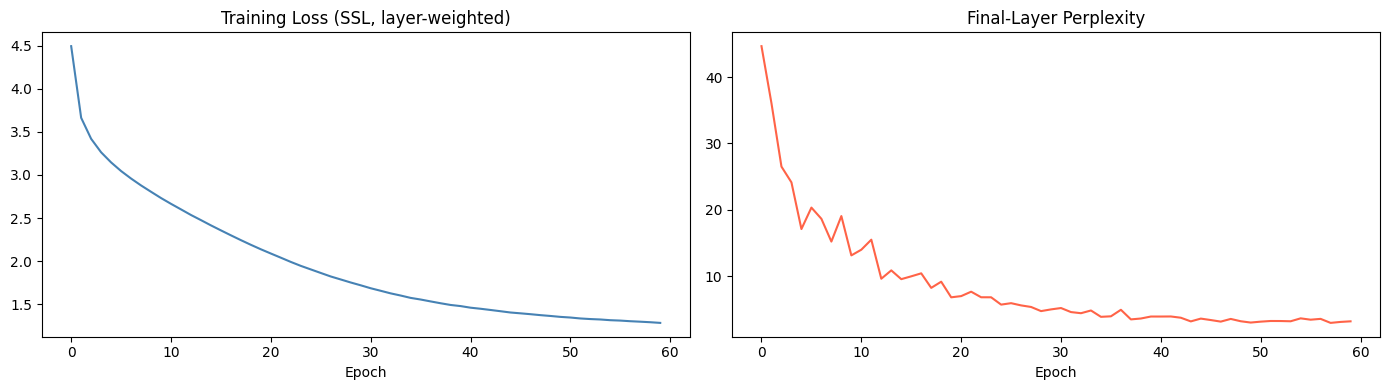

In [8]:
def layer_weights(n, dev):
    w = torch.arange(1, n + 1, dtype=torch.float32, device=dev)
    return w / w.sum()

def ssl_loss(model, ids, pad_id):
    _, logits = model.forward_all_layers(ids[:, :-1])
    tgt = ids[:, 1:]
    wts = layer_weights(len(logits), ids.device)
    total, per = 0.0, []
    for i, lg in enumerate(logits):
        li = F.cross_entropy(lg.reshape(-1, lg.size(-1)),
                             tgt.reshape(-1), ignore_index=pad_id)
        per.append(li.item())
        total = total + wts[i] * li
    return total, per

# ── build tokenizer + dataset ──────────────────────────────────────────
lines_raw = Path(CORPUS_PATH).read_text(encoding="utf-8", errors="ignore").splitlines()
tokenizer = WordTokenizer.build(lines_raw, max_vocab_size=CFG["vocab_size"])
tokenizer.save(CKPT_DIR / "vocab.json")
print(f"Vocab size: {len(tokenizer)}")

ds = AutocompleteDataset(lines_raw, tokenizer, max_len=CFG["max_len"])

# FIX: sanity check — catch tokenizer/model size mismatches here,
# not as a confusing CUDA error several cells later
max_id_in_data = max(max(ex) for ex in ds.examples)
assert max_id_in_data < len(tokenizer), (
    f"Token id {max_id_in_data} >= vocab size {len(tokenizer)}. "
    "Tokenizer and data are out of sync. Restart kernel and Run All.")
assert CFG["max_len"] <= 64, (
    f"max_len={CFG['max_len']} exceeds model max_seq_len=64. "
    "Increase max_seq_len in TinyGPTConfig or reduce max_len in CFG.")
print(f"Sanity checks passed: max_token_id={max_id_in_data} < vocab={len(tokenizer)}")

dl = DataLoader(ds, batch_size=CFG["batch_size"], shuffle=True,
                collate_fn=lambda b: collate_batch(b, tokenizer.pad_id))

# ── build model ────────────────────────────────────────────────────────
cfg = TinyGPTConfig(
    vocab_size=len(tokenizer), d_model=CFG["d_model"],
    n_layer=CFG["n_layer"],    n_head=CFG["n_head"],
    d_ff=CFG["d_ff"],          max_seq_len=CFG["max_len"])
model = TinyGPT(cfg).to(device)
print(f"Model params: {model.num_params():,}")

opt = torch.optim.AdamW(model.parameters(), lr=CFG["lr"])
losses, ppls = [], []

model.train()
for epoch in range(CFG["ssl_epochs"]):
    tot, n_batches = 0.0, 0
    for ids, _ in dl:
        ids = ids.to(device)
        loss, per = ssl_loss(model, ids, tokenizer.pad_id)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tot += loss.item(); n_batches += 1
    avg = tot / n_batches
    ppl = math.exp(min(per[-1], 20))   # cap exp to avoid overflow during early epochs
    losses.append(avg); ppls.append(ppl)
    if (epoch + 1) % 5 == 0:
        print(f"  epoch {epoch+1}/{CFG['ssl_epochs']}  loss={avg:.4f}  ppl={ppl:.2f}")

torch.save({"model": model.state_dict(), "cfg": cfg}, CKPT_DIR / "backbone.pt")
print("\nBackbone saved ✓")

# ── training curve ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(losses, color="steelblue")
ax1.set_title("Training Loss (SSL, layer-weighted)"); ax1.set_xlabel("Epoch")
ax2.plot(ppls, color="tomato")
ax2.set_title("Final-Layer Perplexity"); ax2.set_xlabel("Epoch")
plt.tight_layout(); plt.show()


## 8. Stage 2a — Exit-Classifier Training

  epoch 5/30  classifier loss=0.2146
  epoch 10/30  classifier loss=0.2146
  epoch 15/30  classifier loss=0.2144
  epoch 20/30  classifier loss=0.2142
  epoch 25/30  classifier loss=0.2141
  epoch 30/30  classifier loss=0.2142
Model with exit classifiers saved ✓


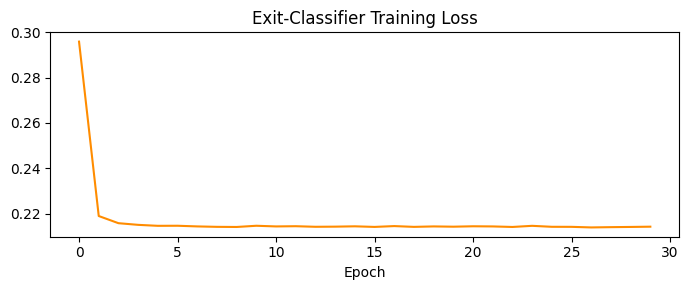

In [9]:
for p in model.parameters(): p.requires_grad = False
for p in model.exit_cls.parameters(): p.requires_grad = True
opt2 = torch.optim.AdamW(model.exit_cls.parameters(), lr=1e-3)
cls_losses = []

model.eval()
for epoch in range(CFG["exit_epochs"]):
    tot, n = 0.0, 0
    for ids, mask in dl:
        ids = ids.to(device)
        with torch.no_grad():
            hs, logits = model.forward_all_layers(ids[:,:-1])
        final_pred = logits[-1].argmax(-1)
        m = mask[:,1:].to(device)
        loss = 0.0
        for i in range(cfg.n_layer - 1):
            oracle = (logits[i].argmax(-1) == final_pred).float()
            score  = model.exit_cls[i](hs[i]).squeeze(-1)
            bce    = F.binary_cross_entropy_with_logits(score, oracle, reduction="none")
            loss   = loss + (bce*m).sum() / m.sum().clamp_min(1)
        loss = loss / (cfg.n_layer - 1)
        opt2.zero_grad(); loss.backward(); opt2.step()
        tot += loss.item(); n += 1
    avg = tot/n; cls_losses.append(avg)
    if (epoch+1) % 5 == 0:
        print(f"  epoch {epoch+1}/{CFG['exit_epochs']}  classifier loss={avg:.4f}")

for p in model.parameters(): p.requires_grad = True
torch.save({"model": model.state_dict(), "cfg": cfg}, CKPT_DIR / "model_with_exits.pt")
print("Model with exit classifiers saved ✓")

plt.figure(figsize=(7,3))
plt.plot(cls_losses, color="darkorange")
plt.title("Exit-Classifier Training Loss"); plt.xlabel("Epoch"); plt.tight_layout(); plt.show()


## 8b. Stage 2b — Learn Composite Weights from Data

Instead of using AUEP's fixed weights, fit a logistic regression on the four
signals against the oracle label (does this layer agree with the final layer?).
The fitted coefficients become the data-driven composite weights.


Learned composite weights:
  confidence    : 0.0744
  entropy       : 0.0560
  margin        : 0.7963
  consistency   : 0.0734
  → saved to /kaggle/working/checkpoints/composite_weights.json


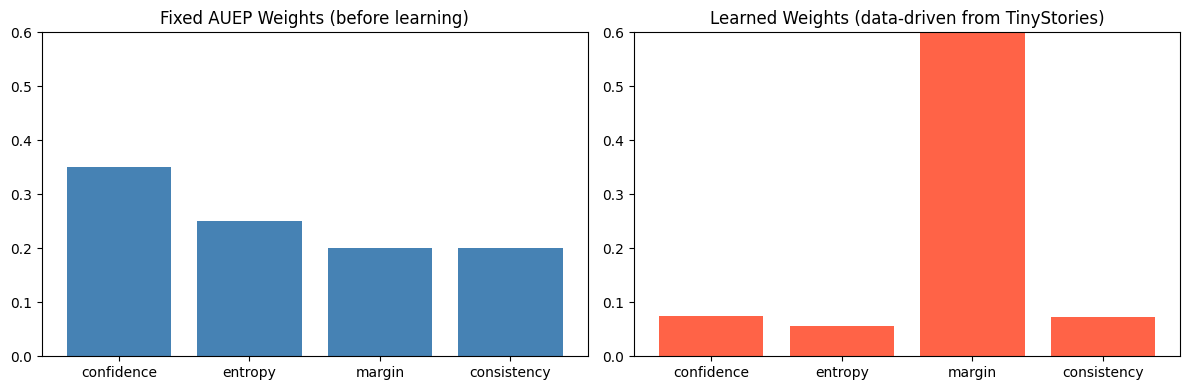

In [10]:
from collections import defaultdict
import torch.optim as optim_mod   # avoid shadowing outer 'optim' name

feat_data   = defaultdict(list)
oracle_data = defaultdict(list)
model.eval()

sample_lines = lines_raw[:2000]
with torch.no_grad():
    for line in sample_lines:
        if not line.strip(): continue
        ids_enc = tokenizer.encode(line.strip())[:CFG["max_len"]]
        if len(ids_enc) < 3: continue
        x_in = torch.tensor([ids_enc[:-1]], device=device)
        hs, logits = model.forward_all_layers(x_in)
        final_pred = logits[-1].argmax(-1)
        prev_preds_per_pos = [[] for _ in range(x_in.shape[1])]

        for i in range(cfg.n_layer - 1):
            lf = logits[i]   # B, T, V
            for pos_idx in range(lf.shape[1]):
                lg_pos = lf[0, pos_idx:pos_idx+1, :]   # 1, V
                pp     = prev_preds_per_pos[pos_idx]
                # FIX: renamed loop vars to avoid collision with outer 'n'
                c_val = _conf(lg_pos)
                e_val = _entropy(lg_pos)
                m_val = _margin(lg_pos)
                k_val = _consistency(lg_pos, pp)
                oracle_val = int((lf[0, pos_idx].argmax() == final_pred[0, pos_idx]).item())
                feat_data[i].append([c_val, 1 - e_val, m_val, k_val])
                oracle_data[i].append(oracle_val)
                prev_preds_per_pos[pos_idx].append(lf[0, pos_idx:pos_idx+1].argmax(-1))

# ── fit logistic regression per layer, average coefficients ────────────
all_coefs = []
for layer_i in range(cfg.n_layer - 1):
    X = torch.tensor(feat_data[layer_i], dtype=torch.float32, device=device)
    y = torch.tensor(oracle_data[layer_i], dtype=torch.float32, device=device)
    if X.shape[0] < 10: continue
    X_min, X_max = X.min(0).values, X.max(0).values
    X_norm = (X - X_min) / (X_max - X_min + 1e-8)
    w_lr = nn.Parameter(torch.ones(4, device=device))
    b_lr = nn.Parameter(torch.zeros(1, device=device))
    opt_lr = optim_mod.Adam([w_lr, b_lr], lr=0.05)
    for _ in range(200):
        logit_lr = X_norm @ w_lr + b_lr
        loss_lr  = F.binary_cross_entropy_with_logits(logit_lr, y)
        opt_lr.zero_grad(); loss_lr.backward(); opt_lr.step()
    coef = F.softmax(w_lr.detach().abs(), dim=0).cpu().tolist()
    all_coefs.append(coef)

signal_names = ["confidence", "entropy", "margin", "consistency"]
if all_coefs:
    avg_coef = [sum(c[j] for c in all_coefs) / len(all_coefs) for j in range(4)]
    COMPOSITE_WEIGHTS.update(dict(zip(signal_names, avg_coef)))
    print("Learned composite weights:")
    for name_w, val_w in COMPOSITE_WEIGHTS.items():
        print(f"  {name_w:<14}: {val_w:.4f}")

    # FIX: save learned weights to disk so they survive a kernel crash
    weights_path = CKPT_DIR / "composite_weights.json"
    weights_path.write_text(json.dumps(COMPOSITE_WEIGHTS), encoding="utf-8")
    print(f"  → saved to {weights_path}")

    # ── weights comparison chart ────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fixed   = [0.35, 0.25, 0.20, 0.20]
    learned = [COMPOSITE_WEIGHTS[sn] for sn in signal_names]
    axes[0].bar(signal_names, fixed,   color="steelblue")
    axes[0].set_title("Fixed AUEP Weights (before learning)")
    axes[0].set_ylim(0, 0.6)
    axes[1].bar(signal_names, learned, color="tomato")
    axes[1].set_title("Learned Weights (data-driven from TinyStories)")
    axes[1].set_ylim(0, 0.6)
    plt.tight_layout(); plt.show()
else:
    print("Not enough data for weight learning; keeping default weights.")

# ── reload learned weights if weights file already exists (restart-safe) ──
def load_weights_if_saved():
    wp = CKPT_DIR / "composite_weights.json"
    if wp.exists():
        w = json.loads(wp.read_text(encoding="utf-8"))
        COMPOSITE_WEIGHTS.update(w)
        print(f"Loaded saved composite weights from {wp}")


## 9. Signal Breakdown Analysis

Signal breakdown across ALL layers (avg over prompts):
 layer     conf     entr     marg     cons     comp
------------------------------------------------
  L 1      0.706    0.152    0.583    1.000    0.638
  L 2      0.702    0.153    0.593    1.000    0.645
  L 3      0.687    0.155    0.559    1.000    0.617
  L 4      0.671    0.152    0.529    1.000    0.592
  L 5      0.663    0.155    0.518    1.000    0.582
  L 6      0.643    0.164    0.497    1.000    0.564
  L 7      0.634    0.172    0.498    1.000    0.563
  L 8      0.625    0.175    0.484    1.000    0.551


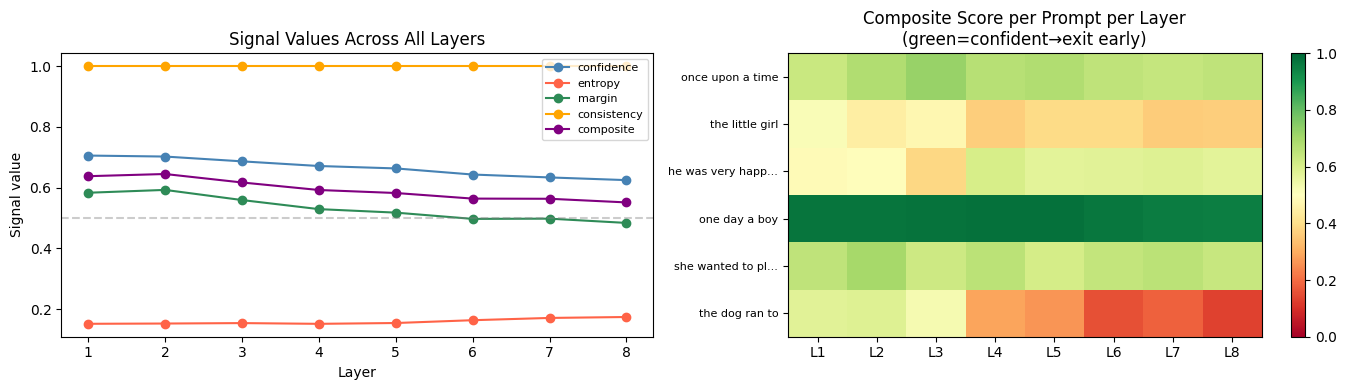


Note: consistency=1.0 at early layers is expected on common story phrases.
It becomes discriminative at deeper layers on ambiguous continuations.


In [11]:
test_prompts = [
    "once upon a time",
    "the little girl",
    "he was very happy",
    "one day a boy",
    "she wanted to play",
    "the dog ran to",
]

model.eval()

# ── per-prompt breakdown at every layer ────────────────────────────────
print("Signal breakdown across ALL layers (avg over prompts):")
print(f"{'layer':>6} {'conf':>8} {'entr':>8} {'marg':>8} {'cons':>8} {'comp':>8}")
print("-" * 48)

layer_avgs = {k: [] for k in ["confidence", "entropy", "margin", "consistency", "composite"]}

for layer_idx in range(cfg.n_layer):
    layer_conf, layer_entr, layer_marg, layer_cons, layer_comp = [], [], [], [], []
    for prompt in test_prompts:
        ids_enc = tokenizer.encode(prompt)[:-1]
        x = torch.tensor([ids_enc], device=device)
        with torch.no_grad():
            _, logits = model.forward_all_layers(x)
        bd = signal_breakdown(logits[layer_idx][:, -1:, :])
        layer_conf.append(bd["confidence"]); layer_entr.append(bd["entropy"])
        layer_marg.append(bd["margin"]);     layer_cons.append(bd["consistency"])
        layer_comp.append(bd["composite"])
    avgs = {
        "confidence":  sum(layer_conf)/len(layer_conf),
        "entropy":     sum(layer_entr)/len(layer_entr),
        "margin":      sum(layer_marg)/len(layer_marg),
        "consistency": sum(layer_cons)/len(layer_cons),
        "composite":   sum(layer_comp)/len(layer_comp),
    }
    for k in layer_avgs: layer_avgs[k].append(avgs[k])
    print(f"  L{layer_idx+1:>2}   {avgs['confidence']:>8.3f} {avgs['entropy']:>8.3f} "
          f"{avgs['margin']:>8.3f} {avgs['consistency']:>8.3f} {avgs['composite']:>8.3f}")

# ── chart: how each signal evolves with depth ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
layer_nums = list(range(1, cfg.n_layer + 1))
colors_sig = {"confidence": "steelblue", "entropy": "tomato",
              "margin": "seagreen", "consistency": "orange", "composite": "purple"}
for sig, col in colors_sig.items():
    axes[0].plot(layer_nums, layer_avgs[sig], "o-", color=col, label=sig)
axes[0].set_xlabel("Layer"); axes[0].set_ylabel("Signal value")
axes[0].set_title("Signal Values Across All Layers")
axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.4)
axes[0].legend(fontsize=8); axes[0].set_xticks(layer_nums)

# composite score heatmap per prompt per layer
import numpy as np
heat = []
for prompt in test_prompts:
    row = []
    ids_enc = tokenizer.encode(prompt)[:-1]
    x = torch.tensor([ids_enc], device=device)
    with torch.no_grad():
        _, logits = model.forward_all_layers(x)
    for li in range(cfg.n_layer):
        bd = signal_breakdown(logits[li][:, -1:, :])
        row.append(bd["composite"])
    heat.append(row)
heat = np.array(heat)
im = axes[1].imshow(heat, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
axes[1].set_xticks(range(cfg.n_layer)); axes[1].set_xticklabels([f"L{i+1}" for i in range(cfg.n_layer)])
short = [p[:16]+"..." if len(p)>16 else p for p in test_prompts]
axes[1].set_yticks(range(len(test_prompts))); axes[1].set_yticklabels(short, fontsize=8)
axes[1].set_title("Composite Score per Prompt per Layer\n(green=confident→exit early)")
plt.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()

print("\nNote: consistency=1.0 at early layers is expected on common story phrases.")
print("It becomes discriminative at deeper layers on ambiguous continuations.")


## 10. Stage 3 — LTT Calibration

In [12]:
# FIX: 2000 calibration lines instead of 500 — the Hoeffding bound
# tightens with more samples, allowing a lower (less conservative) lambda.
cal_lines = [l for l in lines_raw if l.strip()][:2000]
print(f"Using {len(cal_lines)} calibration lines")

calibrated_lambda = ltt_calibrate(
    model, tokenizer, cal_lines,
    conf_name="composite",
    delta=0.10, epsilon=0.20, tau=2.0)


Using 2000 calibration lines
Calibrating with 2000 examples, delta=0.1, epsilon=0.2
  λ=1.00  excess=0.0100  p=0.0000  ✓ ACCEPT
  λ=0.95  excess=0.0208  p=0.0000  ✓ ACCEPT
  λ=0.90  excess=0.0320  p=0.0000  ✓ ACCEPT
  λ=0.85  excess=0.0456  p=0.0000  ✓ ACCEPT
  λ=0.80  excess=0.0581  p=0.0009  ✓ ACCEPT
  λ=0.75  excess=0.0763  p=0.1061  ✓ ACCEPT
  λ=0.70  excess=0.0979  p=0.9828  ✗ reject → stop

Calibrated λ = 0.75


## 11. Stage 4 — Full Evaluation

In [13]:
eval_lines = [l for l in lines_raw if l.strip()][-200:]
N_EVAL = 80

def run_eval(measure_name, lam, tau=2.0, n=N_EVAL):
    layers_used, f1g, f1f = [], [], []
    for line in eval_lines[:n]:
        prompt, gold = split_half(line)
        if not gold: continue
        pe, exits = generate_early_exit(model, tokenizer, prompt,
                                         measure_name, lam, tau=tau,
                                         max_new=len(gold))
        pf = generate_full(model, tokenizer, prompt, max_new=len(gold))
        layers_used.extend(exits)
        f1g.append(token_f1(simple_tokenize(pe), gold))
        f1f.append(token_f1(simple_tokenize(pe), simple_tokenize(pf)))
    avg_l = mean(layers_used) if layers_used else cfg.n_layer
    return avg_l, cfg.n_layer/avg_l, mean(f1g), mean(f1f)

# ── Part 1: all four measures at fixed lambda ───────────────────────────
EVAL_LAM = calibrated_lambda if calibrated_lambda < 1.0 else 0.6
print(f"Evaluating at λ={EVAL_LAM}\n")
print(f"{'measure':<12} {'avg_layers':>10} {'speedup':>9} {'F1 gold':>9} {'F1 full':>9}")
print("-"*52)
results = {}
for name in ["softmax","saturation","classifier","composite"]:
    al, sp, fg, ff = run_eval(name, EVAL_LAM)
    results[name] = (al, sp, fg, ff)
    marker = " ← main contribution" if name == "composite" else ""
    print(f"{name:<12} {al:>10.2f} {sp:>8.2f}x {fg:>9.3f} {ff:>9.3f}{marker}")


Evaluating at λ=0.75

measure      avg_layers   speedup   F1 gold   F1 full
----------------------------------------------------
softmax            3.29     2.43x     0.750     0.938
saturation         2.00     4.00x     0.410     0.528
classifier         1.98     4.04x     0.469     0.597
composite          3.22     2.48x     0.731     0.919 ← main contribution



── Ablation: removing one signal at a time from composite ──
variant                avg_layers   speedup   F1 gold   F1 full    Δ F1
--------------------------------------------------------------
Full composite               3.22     2.48x     0.731     0.919  (base)
No confidence                3.22     2.48x     0.740     0.928  +0.009
No entropy                   3.22     2.48x     0.740     0.928  +0.009
No margin                    2.02     3.97x     0.432     0.541  -0.299
No consistency               3.23     2.47x     0.740     0.928  +0.009


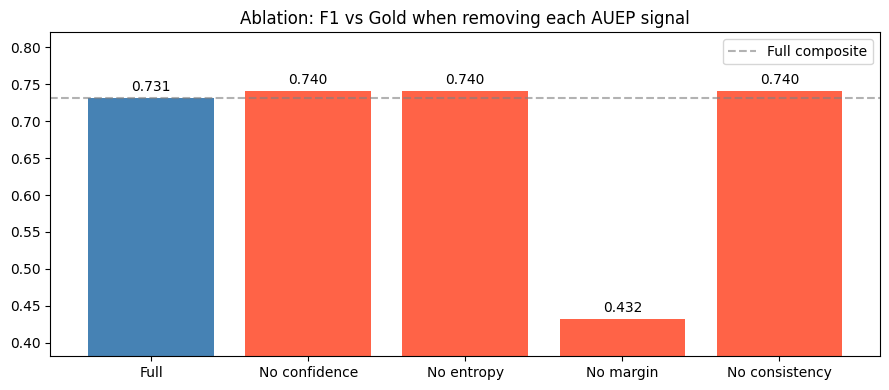


Signal importance (drop in F1 when removed):
  confidence    : +0.0089    (helps)
  entropy       : +0.0089    (helps)
  margin        : -0.2992  █████████████████████████████  (hurts)
  consistency   : +0.0089    (helps)


In [14]:
# FIX: try/finally ensures COMPOSITE_WEIGHTS is always restored
# even if a crash happens mid-ablation.
print("\n── Ablation: removing one signal at a time from composite ──")
print(f"{'variant':<22} {'avg_layers':>10} {'speedup':>9} {'F1 gold':>9} {'F1 full':>9} {'Δ F1':>7}")
print("-" * 62)

base_al, base_sp, base_fg, base_ff = run_eval("composite", EVAL_LAM)
print(f"{'Full composite':<22} {base_al:>10.2f} {base_sp:>8.2f}x "
      f"{base_fg:>9.3f} {base_ff:>9.3f}  (base)")

signal_names_abl = ["confidence", "entropy", "margin", "consistency"]
ablation_results = {}

for drop in signal_names_abl:
    w_orig = dict(COMPOSITE_WEIGHTS)    # save before zeroing
    try:
        COMPOSITE_WEIGHTS[drop] = 0.0
        total_w = sum(COMPOSITE_WEIGHTS.values())
        for k in COMPOSITE_WEIGHTS:
            COMPOSITE_WEIGHTS[k] /= max(total_w, 1e-8)
        al, sp, fg, ff = run_eval("composite", EVAL_LAM)
        ablation_results[drop] = (al, sp, fg, ff)
        print(f"{'No '+drop:<22} {al:>10.2f} {sp:>8.2f}x "
              f"{fg:>9.3f} {ff:>9.3f} {fg - base_fg:>+7.3f}")
    finally:
        COMPOSITE_WEIGHTS.update(w_orig)   # always restore

# ── ablation bar chart ──────────────────────────────────────────────────
labels_abl = ["Full"] + ["No " + s for s in signal_names_abl]
f1s_abl    = [base_fg] + [ablation_results[s][2] for s in signal_names_abl]
colors_abl = ["steelblue"] + ["tomato"] * 4
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels_abl, f1s_abl, color=colors_abl)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_ylim(min(f1s_abl) - 0.05, max(f1s_abl) + 0.08)
ax.set_title("Ablation: F1 vs Gold when removing each AUEP signal")
ax.axhline(base_fg, color="gray", linestyle="--", alpha=0.6, label="Full composite")
ax.legend(); plt.tight_layout(); plt.show()

print("\nSignal importance (drop in F1 when removed):")
for s in signal_names_abl:
    drop_f1 = ablation_results[s][2] - base_fg
    bar = "█" * max(0, int(abs(drop_f1) * 100))
    direction = "hurts" if drop_f1 < 0 else "helps"
    print(f"  {s:<14}: {drop_f1:+.4f}  {bar}  ({direction})")



── Lambda sweep (composite confidence) ──
  lambda avg_layers   speedup   F1 gold   F1 full
------------------------------------------------
    0.20       1.35     5.94x     0.328     0.421
    0.30       1.76     4.53x     0.386     0.523
    0.40       2.15     3.73x     0.463     0.612
    0.50       2.51     3.19x     0.551     0.732
    0.60       2.88     2.78x     0.609     0.790
    0.70       3.08     2.59x     0.710     0.898
    0.80       3.34     2.40x     0.758     0.946
    0.90       3.64     2.20x     0.757     0.964


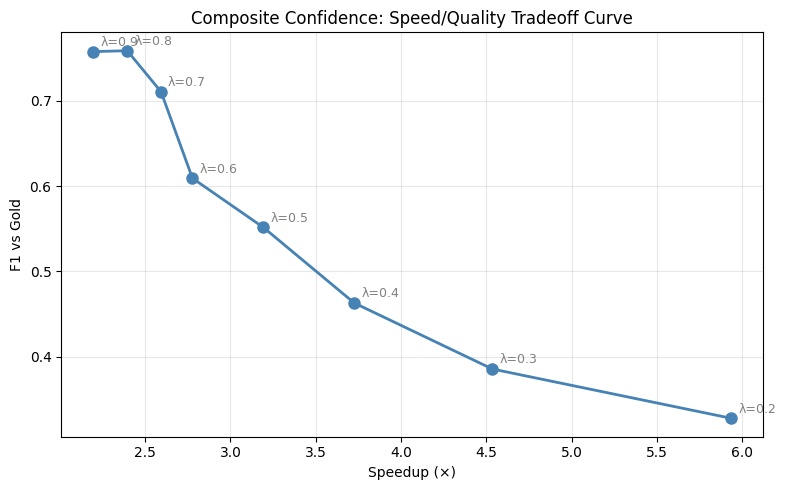

In [15]:
# ── Part 3: Lambda sweep for composite ──────────────────────────────────
print("\n── Lambda sweep (composite confidence) ──")
print(f"{'lambda':>8} {'avg_layers':>10} {'speedup':>9} {'F1 gold':>9} {'F1 full':>9}")
print("-"*48)

sweep_lams = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
sweep_results = []
for lam in sweep_lams:
    al, sp, fg, ff = run_eval("composite", lam)
    sweep_results.append((lam, al, sp, fg, ff))
    print(f"{lam:>8.2f} {al:>10.2f} {sp:>8.2f}x {fg:>9.3f} {ff:>9.3f}")

# ── speed-quality tradeoff curve ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
speedups = [r[2] for r in sweep_results]
f1s_gold = [r[3] for r in sweep_results]
ax.plot(speedups, f1s_gold, "o-", color="steelblue", linewidth=2, markersize=8)
for r in sweep_results:
    ax.annotate(f"λ={r[0]}", (r[2], r[3]), textcoords="offset points",
                xytext=(5, 4), fontsize=9, color="gray")
ax.set_xlabel("Speedup (×)"); ax.set_ylabel("F1 vs Gold")
ax.set_title("Composite Confidence: Speed/Quality Tradeoff Curve")
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## 12. Struggle-Aware Evaluation

The three HCI-derived signals that replace AUEP's fixed FAST/BALANCED/ACCURATE profiles
with a dynamic, per-suggestion threshold adjustment.


In [16]:
from dataclasses import dataclass as dc

@dc
class Keystroke:
    t_ms: float; key: str; is_backspace: bool = False

@dc
class SuggestionEvent:
    t_shown_ms: float; suggestion: str; context_key: str
    accepted: bool; t_decision_ms: float; deleted_after: bool = False


class AttentionTracker:
    def __init__(self, fast=150, ideal=700, slow=2500, window=8):
        self.fast = fast; self.ideal = ideal; self.slow = slow
        self.latencies = deque(maxlen=window)

    def update(self, ev):
        self.latencies.append(max(0, ev.t_decision_ms - ev.t_shown_ms))

    def engagement(self):
        if not self.latencies: return 0.5
        lat = sum(self.latencies) / len(self.latencies)
        if lat <= self.fast:
            return 0.15
        if lat <= self.ideal:
            return 0.15 + 0.7 * (lat - self.fast) / max(self.ideal - self.fast, 1e-6)
        if lat <= self.slow:
            return 0.85 - 0.55 * (lat - self.ideal) / max(self.slow - self.ideal, 1e-6)
        return 0.2


class PostureTracker:
    def __init__(self, window=20, baseline=60):
        self.recent = deque(maxlen=window)
        self.intervals = deque(maxlen=baseline)
        self._last = None

    def update(self, ks):
        if self._last:
            self.intervals.append(max(1.0, ks.t_ms - self._last))
        self._last = ks.t_ms
        self.recent.append(ks)

    def struggle(self):
        if len(self.recent) < 3 or len(self.intervals) < 5: return 0.5
        bs  = sum(1 for k in self.recent if k.is_backspace) / len(self.recent)
        sp  = sum(list(self.intervals)[-5:]) / 5
        bl  = sum(self.intervals) / len(self.intervals)
        deg = max(0.0, (sp - bl) / max(bl, 1.0))
        return min(1.0, 0.6 * min(1.0, bs / 0.3) + 0.4 * min(1.0, deg))


class RejectionTracker:
    def __init__(self, ar=0.08, rr=0.16):
        self.ar = ar; self.rr = rr
        self.diff: Dict[str, float] = {}

    def update(self, ev):
        d = self.diff.get(ev.context_key, 0.5)
        if ev.accepted and not ev.deleted_after:
            d = d - self.ar * d
        else:
            penalty = 2.0 if ev.deleted_after else 1.0
            d = d + self.rr * penalty * (1 - d)
        self.diff[ev.context_key] = min(1.0, max(0.0, d))

    def difficulty_for(self, ctx):
        return self.diff.get(ctx, 0.5)


class StruggleScorer:
    def __init__(self, w_att=0.35, w_pos=0.35, w_rej=0.30):
        self.w = (w_att, w_pos, w_rej)
        self.att = AttentionTracker()
        self.pos = PostureTracker()
        self.rej = RejectionTracker()

    def on_key(self, ks):  self.pos.update(ks)
    def on_sugg(self, ev): self.att.update(ev); self.rej.update(ev)

    def score(self, ctx):
        wa, wp, wr = self.w
        return min(1.0, max(0.0,
            wa * (1 - self.att.engagement()) +
            wp * self.pos.struggle() +
            wr * self.rej.difficulty_for(ctx)))

    def components(self, ctx):
        return {
            "engagement":           round(self.att.engagement(), 3),
            "posture_struggle":     round(self.pos.struggle(), 3),
            "rejection_difficulty": round(self.rej.difficulty_for(ctx), 3),
            "combined_struggle":    round(self.score(ctx), 3),
        }


def simulate_session(state="calm", n_words=30, seed=0):
    rng = random.Random(seed)
    t, ks, evs, prev = 0.0, [], [], "<bos>"
    for w in range(n_words):
        wl = rng.randint(2, 7)
        # FIX: removed backslash continuation — use parentheses instead
        if state == "calm":
            base = rng.uniform(90, 160)
        else:
            base = rng.uniform(110, 220) * (1 + 0.03 * w)
        for _ in range(wl):
            t += max(40, rng.gauss(base, base * 0.25))
            bs = (state == "struggling") and (rng.random() < 0.18)
            if bs: t += rng.uniform(50, 150)
            ks.append(Keystroke(t, "x", bs))
        ts = t
        if state == "calm":
            lat = max(80, rng.gauss(650, 250))
            acc = rng.random() < 0.82
            del_ = acc and (rng.random() < 0.04)
        else:
            if rng.random() < 0.5:
                lat = max(50, rng.gauss(120, 40))
            else:
                lat = max(1500, rng.gauss(2800, 700))
            acc  = rng.random() < 0.55
            del_ = acc and (rng.random() < 0.22)
        td = ts + lat
        evs.append(SuggestionEvent(ts, f"w{w}", prev, acc, td, del_))
        t = td; prev = f"w{w}"
    return ks, evs

print("Struggle-aware classes defined ✓")


Struggle-aware classes defined ✓


Struggle Signal Breakdown per Session

[calm]
  engagement                = 0.846
  posture_struggle          = 0.042
  rejection_difficulty      = 0.500
  combined_struggle         = 0.219

[struggling]
  engagement                = 0.603
  posture_struggle          = 0.682
  rejection_difficulty      = 0.500
  combined_struggle         = 0.528

Autocomplete: flat CALM vs struggle-aware CALM
session      mode               avg_layers   speedup   F1 gold
-------------------------------------------------------
calm         flat CALM                3.19     2.51x     0.745
calm         struggle-aware           2.50     3.20x     0.568
struggling   flat CALM                3.19     2.51x     0.745
struggling   struggle-aware           3.24     2.47x     0.745


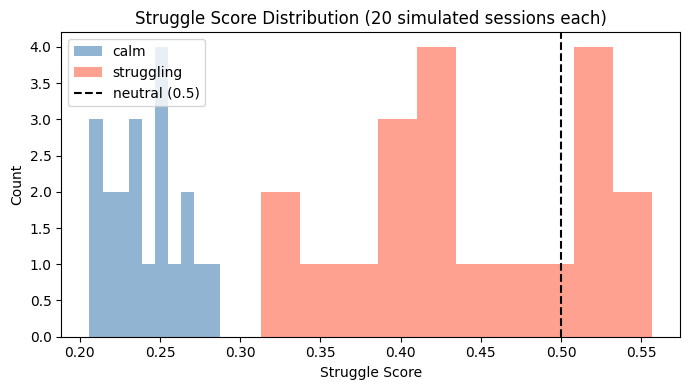

In [17]:
# ── run both simulated sessions and compare ────────────────────────────
print("="*70)
print("Struggle Signal Breakdown per Session")
print("="*70)

session_scores = {}
for state in ["calm","struggling"]:
    ks, evs = simulate_session(state, n_words=30)
    scorer  = StruggleScorer()
    events  = sorted([(k.t_ms,"k",k) for k in ks]+[(e.t_decision_ms,"s",e) for e in evs],
                     key=lambda x:x[0])
    for _,kind,ev in events:
        if kind=="k": scorer.on_key(ev)
        else:         scorer.on_sugg(ev)
    comp = scorer.components("<unseen>")
    session_scores[state] = comp["combined_struggle"]
    print(f"\n[{state}]")
    for k,v in comp.items(): print(f"  {k:<25} = {v:.3f}")

print("\n" + "="*70)
print("Autocomplete: flat CALM vs struggle-aware CALM")
print("="*70)
print(f"{'session':<12} {'mode':<18} {'avg_layers':>10} {'speedup':>9} {'F1 gold':>9}")
print("-"*55)

for state, ss in session_scores.items():
    for mode, use_s in [("flat CALM","no"), ("struggle-aware","yes")]:
        ls_used, f1s = [], []
        for line in eval_lines[:40]:
            prompt, gold = split_half(line)
            if not gold: continue
            pe, exits = generate_early_exit(
                model, tokenizer, prompt, "composite", EVAL_LAM,
                tau=2.0, max_new=len(gold),
                struggle_score=(ss if use_s=="yes" else None))
            ls_used.extend(exits)
            f1s.append(token_f1(simple_tokenize(pe), gold))
        al = mean(ls_used) if ls_used else cfg.n_layer
        print(f"{state:<12} {mode:<18} {al:>10.2f} {cfg.n_layer/al:>8.2f}x {mean(f1s):>9.3f}")

# ── struggle score distribution plot ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
scores_calm = []
scores_strug = []
for seed in range(20):
    for state, lst in [("calm",scores_calm),("struggling",scores_strug)]:
        ks, evs = simulate_session(state, n_words=20, seed=seed)
        sc = StruggleScorer()
        for _,kind,ev in sorted([(k.t_ms,"k",k) for k in ks]+[(e.t_decision_ms,"s",e) for e in evs],key=lambda x:x[0]):
            if kind=="k": sc.on_key(ev)
            else: sc.on_sugg(ev)
        lst.append(sc.score("<unseen>"))
ax.hist(scores_calm,  bins=10, alpha=0.6, color="steelblue", label="calm")
ax.hist(scores_strug, bins=10, alpha=0.6, color="tomato",    label="struggling")
ax.axvline(0.5, color="black", linestyle="--", label="neutral (0.5)")
ax.set_xlabel("Struggle Score"); ax.set_ylabel("Count")
ax.set_title("Struggle Score Distribution (20 simulated sessions each)")
ax.legend(); plt.tight_layout(); plt.show()


## 13. Live Next-Word Demo

In [18]:
@torch.no_grad()
def next_word(prompt, top_k=3, conf="composite", lam=0.6):
    model.eval()
    ids = tokenizer.encode(prompt)[:-1]
    kc, vc = model.init_kv()
    for t, tok in enumerate(ids[:-1]):
        _, _, kc, vc = model.decode_step(
            torch.tensor([[tok]], device=device), t, kc, vc,
            lambda **kw: torch.zeros(1), lambda **kw: 2.0)
    logits_full = model.forward_full(
        torch.tensor([ids[-model.cfg.max_seq_len:]], device=device))[0, -1]
    probs_full = F.softmax(logits_full, -1).topk(top_k)
    full_sugg  = [(tokenizer.id2tok.get(i.item(), "<unk>"), p.item())
                  for p, i in zip(probs_full.values, probs_full.indices)]
    conf_fn  = CONFIDENCE_MEASURES[conf]
    thresh   = make_threshold(lam)
    tok_t    = torch.tensor([[ids[-1]]], device=device)
    logits_e, el, _, _ = model.decode_step(tok_t, len(ids) - 1, kc, vc, conf_fn, thresh)
    probs_e  = F.softmax(logits_e[0, 0], -1).topk(top_k)
    exit_sugg = [(tokenizer.id2tok.get(i.item(), "<unk>"), p.item())
                 for p, i in zip(probs_e.values, probs_e.indices)]
    return full_sugg, exit_sugg, el


# ── 30 TinyStories prompts across 5 categories ─────────────────────────
# The model was trained on TinyStories — short, simple children's stories.
# Prompts are grouped by theme so you can see if the model learned
# story-specific patterns (characters, emotions, actions, places, endings).

prompts_by_category = {

    "Characters & People": [
        "once upon a time",
        "the little girl",
        "one day a boy",
        "his mother said",
        "the old man",
        "a young princess",
    ],

    "Emotions & Feelings": [
        "he was very happy",
        "she felt so sad",
        "the boy started to",
        "she was surprised to",
        "he smiled and",
        "they were excited to",
    ],

    "Actions & Events": [
        "she wanted to play",
        "the dog ran to",
        "he decided to go",
        "she picked up the",
        "he jumped over the",
        "they ran as fast",
    ],

    "Places & Settings": [
        "in the forest there",
        "near the big tree",
        "at the park the",
        "inside the small house",
        "by the river a",
        "in a little town",
    ],

    "Story Endings": [
        "they lived happily ever",
        "the end of the",
        "from that day on",
        "and they all learned",
        "she never forgot the",
        "everyone was very proud",
    ],
}

# ── Section 1: grouped table ────────────────────────────────────────────
for category, prompts in prompts_by_category.items():
    print(f"\n{'='*100}")
    print(f"  {category}")
    print(f"{'='*100}")
    print(f"  {'Prompt':<26} {'Full model top-3':<40} {'Early-exit top-3':<38} {'Exit layer'}")
    print(f"  {'-'*96}")
    for prompt in prompts:
        fs, es, el = next_word(prompt, conf="composite", lam=EVAL_LAM)
        full_str  = " | ".join(f"{w}({p:.2f})" for w, p in fs)
        early_str = " | ".join(f"{w}({p:.2f})" for w, p in es)
        match = "✓" if fs[0][0] == es[0][0] else "✗"
        print(f"  {match} {prompt:<25} {full_str:<40} {early_str:<38}  {el}/{cfg.n_layer}")

# ── Section 2: overall top-1 agreement ─────────────────────────────────
all_prompts = [p for prompts in prompts_by_category.values() for p in prompts]
print(f"\n{'='*70}")
print("Full vs Early-exit Top-1 Agreement — all 30 prompts")
print(f"{'='*70}")
agree, total = 0, 0
cat_agree = {}
for category, prompts in prompts_by_category.items():
    cat_ok = 0
    for prompt in prompts:
        fs, es, el = next_word(prompt, conf="composite", lam=EVAL_LAM)
        if fs[0][0] == es[0][0]:
            agree += 1; cat_ok += 1
        total += 1
    cat_agree[category] = (cat_ok, len(prompts))

for category, (ok, tot) in cat_agree.items():
    bar = "█" * ok + "░" * (tot - ok)
    print(f"  {category:<30}: {ok}/{tot}  {bar}")

pct = 100 * agree / total
print(f"\n  Overall: {agree}/{total} = {pct:.0f}% agreement")
if pct >= 80:
    print("  → Good: early-exit agrees with full model on most prompts")
elif pct >= 60:
    print("  → Acceptable: consider more training epochs for better alignment")
else:
    print("  → Low: model needs more training or use a higher lambda")

# ── Section 3: exit layer distribution per category ────────────────────
print(f"\n── Average Exit Layer per Category (lower = more compute saved) ──")
for category, prompts in prompts_by_category.items():
    cat_exits = []
    for prompt in prompts:
        _, _, el = next_word(prompt, conf="composite", lam=EVAL_LAM)
        cat_exits.append(el)
    avg_exit = sum(cat_exits) / len(cat_exits)
    saved    = (1 - avg_exit / cfg.n_layer) * 100
    bar      = "█" * int(saved / 10)
    print(f"  {category:<30}: avg layer={avg_exit:.1f}/{cfg.n_layer}  saved={saved:.0f}%  {bar}")

# ── Section 4: confidence measure comparison on sample prompts ──────────
sample_prompts = [
    "once upon a time",
    "she felt so sad",
    "they lived happily ever",
    "in the forest there",
]
print(f"\n── Confidence Measure Comparison on 4 Sample Prompts ──")
print(f"  {'prompt':<24} {'measure':<12} {'top-1 word':<14} {'exit layer'}")
print(f"  {'-'*64}")
for prompt in sample_prompts:
    for mname in ["softmax", "saturation", "classifier", "composite"]:
        fs, es, el = next_word(prompt, conf=mname, lam=EVAL_LAM)
        match = "✓" if fs[0][0] == es[0][0] else "✗"
        print(f"  {match} {prompt:<24} {mname:<12} {es[0][0]:<14} {el}/{cfg.n_layer}")
    print()



  Characters & People
  Prompt                     Full model top-3                         Early-exit top-3                       Exit layer
  ------------------------------------------------------------------------------------------------
  ✓ once upon a time          ,(0.79) | there(0.20) | in(0.00)         ,(0.79) | there(0.20) | in(0.00)        8/8
  ✓ the little girl           was(0.37) | smiled(0.09) | and(0.07)     was(0.37) | smiled(0.09) | and(0.07)    8/8
  ✓ one day a boy             named(0.96) | and(0.01) | went(0.00)     named(0.97) | who(0.01) | heard(0.01)   1/8
  ✓ his mother said           ,(1.00) | yes(0.00) | oh(0.00)           ,(0.92) | they(0.02) | to(0.01)         1/8
  ✓ the old man               smiled(0.20) | was(0.19) | had(0.09)     smiled(0.20) | was(0.19) | had(0.09)    8/8
  ✓ a young princess          was(0.63) | saw(0.23) | came(0.04)       was(0.79) | knew(0.04) | didn't(0.03)   1/8

  Emotions & Feelings
  Prompt                     Full model top-3

## 14. Results Summary

In [19]:
# FIX: guard all variables that depend on earlier cells
missing = []
if 'results'         not in dir(): missing.append('results (run cell 11 Part 1)')
if 'sweep_results'   not in dir(): missing.append('sweep_results (run cell 11 Part 3)')
if 'session_scores'  not in dir(): missing.append('session_scores (run cell 12)')
if missing:
    print("ERROR: the following are not defined yet. Run those cells first:")
    for m in missing: print(f"  - {m}")
else:
    print("="*70)
    print("FINAL RESULTS SUMMARY")
    print("="*70)

    print(f"\nModel:  {model.num_params():,} parameters | {cfg.n_layer} layers | d_model={cfg.d_model}")
    print(f"Vocab:  {len(tokenizer)} tokens")
    print(f"Data:   TinyStories GPT4-valid split — {len(lines_raw)} sentences prepared")
    print(f"        (Note: validation split used for speed; state this in any paper submission)")
    print(f"Lambda: {EVAL_LAM} (LTT-calibrated, Hoeffding bound, ε=0.20, δ=0.10)")

    print("\n── All Measures at λ={} ──".format(EVAL_LAM))
    print(f"{'measure':<12} {'avg_layers':>10} {'speedup':>9} {'F1 gold':>9} {'F1 full':>9} {'compute saved':>14}")
    print("-"*66)
    for name in ["softmax", "saturation", "classifier", "composite"]:
        al, sp, fg, ff = results[name]
        saved = (1 - al / cfg.n_layer) * 100
        marker = " ← main contribution" if name == "composite" else ""
        print(f"{name:<12} {al:>10.2f} {sp:>8.2f}x {fg:>9.3f} {ff:>9.3f} {saved:>12.1f}%{marker}")

    print("\n── Learned Composite Weights (data-driven, not fixed) ──")
    for k, v in COMPOSITE_WEIGHTS.items():
        bar = "█" * int(v * 30)
        print(f"  {k:<14}: {v:.4f}  {bar}")

    print("\n── Struggle Score Separation ──")
    for state, ss in session_scores.items():
        direction = ("→ exit EARLIER (save compute)"
                     if ss < 0.5 else "→ exit LATER (be careful)")
        print(f"  {state:<12}: {ss:.3f}  {direction}")

    print("\n── Best Operating Point (composite confidence) ──")
    best = min(sweep_results, key=lambda r: abs(r[3] - 0.85))
    print(f"  Lambda = {best[0]}  |  Speedup = {best[2]:.2f}x  |  F1 = {best[3]:.3f}")
    print(f"  Saves {(1 - best[1] / cfg.n_layer) * 100:.1f}% of decoder compute")

    print("\nDone ✓")


FINAL RESULTS SUMMARY

Model:  15,767,047 parameters | 8 layers | d_model=384
Vocab:  4055 tokens
Data:   TinyStories GPT4-valid split — 20000 sentences prepared
        (Note: validation split used for speed; state this in any paper submission)
Lambda: 0.75 (LTT-calibrated, Hoeffding bound, ε=0.20, δ=0.10)

── All Measures at λ=0.75 ──
measure      avg_layers   speedup   F1 gold   F1 full  compute saved
------------------------------------------------------------------
softmax            3.29     2.43x     0.750     0.938         58.8%
saturation         2.00     4.00x     0.410     0.528         75.0%
classifier         1.98     4.04x     0.469     0.597         75.2%
composite          3.22     2.48x     0.731     0.919         59.7% ← main contribution

── Learned Composite Weights (data-driven, not fixed) ──
  confidence    : 0.0744  ██
  entropy       : 0.0560  █
  margin        : 0.7963  ███████████████████████
  consistency   : 0.0734  ██

── Struggle Score Separation ──
  calm

## 15. Download All — Models + Graphs

Run this cell after all other cells have finished.
It saves every model checkpoint and every graph to a ZIP file
that you can download from Kaggle's output panel.

**How to download on Kaggle:**
1. Run this cell
2. Look at the right panel → **Output** tab
3. Find `early_exit_results.zip`
4. Click the download arrow next to it


In [20]:
import zipfile, shutil, os
import matplotlib
matplotlib.use("Agg")   # non-interactive backend so savefig works without display
import matplotlib.pyplot as plt
import numpy as np

PLOTS_DIR = BASE_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

# ── helper: save any figure cleanly ────────────────────────────────────
def savefig(name):
    path = str(PLOTS_DIR / name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  saved → {path}")

# ══════════════════════════════════════════════════════════════════════
# GRAPH 1 — Training loss + perplexity
# ══════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
if "losses" in dir() and losses:
    ax1.plot(losses, color="steelblue", linewidth=2)
    ax1.set_title("Stage 1 — Training Loss (SSL Layer-Weighted)")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.grid(True, alpha=0.3)
if "ppls" in dir() and ppls:
    ax2.plot(ppls, color="tomato", linewidth=2)
    ax2.set_title("Stage 1 — Final-Layer Perplexity")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Perplexity")
    ax2.grid(True, alpha=0.3)
plt.tight_layout()
savefig("01_training_loss_perplexity.png")

# ══════════════════════════════════════════════════════════════════════
# GRAPH 2 — Exit classifier loss
# ══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(7, 4))
if "cls_losses" in dir() and cls_losses:
    ax.plot(cls_losses, color="darkorange", linewidth=2)
ax.set_title("Stage 2 — Exit Classifier Training Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig("02_exit_classifier_loss.png")

# ══════════════════════════════════════════════════════════════════════
# GRAPH 3 — Composite weight comparison (fixed vs learned)
# ══════════════════════════════════════════════════════════════════════
signal_names = ["confidence", "entropy", "margin", "consistency"]
fixed_w      = [0.35, 0.25, 0.20, 0.20]
learned_w    = [COMPOSITE_WEIGHTS.get(s, 0.25) for s in signal_names]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
b1 = axes[0].bar(signal_names, fixed_w, color="steelblue")
axes[0].bar_label(b1, fmt="%.3f", padding=3)
axes[0].set_title("Fixed AUEP Weights (before learning)")
axes[0].set_ylim(0, 0.6); axes[0].set_ylabel("Weight")

b2 = axes[1].bar(signal_names, learned_w, color="tomato")
axes[1].bar_label(b2, fmt="%.3f", padding=3)
axes[1].set_title("Learned Composite Weights (from TinyStories data)")
axes[1].set_ylim(0, 0.6)
plt.suptitle("Composite Confidence — Fixed vs Learned Weights", fontsize=13, y=1.02)
plt.tight_layout()
savefig("03_composite_weights_comparison.png")

# ══════════════════════════════════════════════════════════════════════
# GRAPH 4 — Signal values across all layers (heatmap)
# ══════════════════════════════════════════════════════════════════════
test_prompts_plot = [
    "once upon a time", "the little girl", "he was very happy",
    "one day a boy",    "she wanted to",   "the dog ran to",
]
heat_data = []
model.eval()
with torch.no_grad():
    for prompt in test_prompts_plot:
        row = []
        ids_enc = tokenizer.encode(prompt)[:-1]
        x = torch.tensor([ids_enc], device=device)
        _, logits = model.forward_all_layers(x)
        for li in range(cfg.n_layer):
            bd = signal_breakdown(logits[li][:, -1:, :])
            row.append(bd["composite"])
        heat_data.append(row)

heat_arr = np.array(heat_data)
short_p  = [p[:18]+"..." if len(p)>18 else p for p in test_prompts_plot]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].imshow(heat_arr, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
axes[0].set_xticks(range(cfg.n_layer))
axes[0].set_xticklabels([f"L{i+1}" for i in range(cfg.n_layer)])
axes[0].set_yticks(range(len(test_prompts_plot)))
axes[0].set_yticklabels(short_p, fontsize=9)
axes[0].set_title("Composite Score per Prompt per Layer\n(green=confident, red=uncertain)")
plt.colorbar(im, ax=axes[0])

layer_nums = list(range(1, cfg.n_layer + 1))
colors_sig = {"confidence":"steelblue","entropy":"tomato",
              "margin":"seagreen","consistency":"orange","composite":"purple"}
for sig, col in colors_sig.items():
    vals = []
    with torch.no_grad():
        for li in range(cfg.n_layer):
            sig_vals = []
            for prompt in test_prompts_plot:
                ids_enc = tokenizer.encode(prompt)[:-1]
                x = torch.tensor([ids_enc], device=device)
                _, logits = model.forward_all_layers(x)
                bd = signal_breakdown(logits[li][:, -1:, :])
                sig_vals.append(bd[sig])
            vals.append(sum(sig_vals)/len(sig_vals))
    axes[1].plot(layer_nums, vals, "o-", color=col, label=sig, linewidth=2)
axes[1].set_xlabel("Layer"); axes[1].set_ylabel("Signal value")
axes[1].set_title("All Signals Across Layers (avg over prompts)")
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.4, label="threshold")
axes[1].legend(fontsize=8); axes[1].set_xticks(layer_nums)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
savefig("04_signal_analysis_heatmap.png")

# ══════════════════════════════════════════════════════════════════════
# GRAPH 5 — Lambda sweep: speed / quality tradeoff curve
# ══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if "sweep_results" in dir() and sweep_results:
    lams     = [r[0] for r in sweep_results]
    speedups = [r[2] for r in sweep_results]
    f1s      = [r[3] for r in sweep_results]

    axes[0].plot(speedups, f1s, "o-", color="steelblue", linewidth=2, markersize=8)
    for r in sweep_results:
        axes[0].annotate(f"λ={r[0]}", (r[2], r[3]),
                         textcoords="offset points", xytext=(5, 4), fontsize=9)
    axes[0].set_xlabel("Speedup (×)"); axes[0].set_ylabel("F1 vs Gold")
    axes[0].set_title("Composite Confidence: Speed / Quality Tradeoff")
    axes[0].grid(True, alpha=0.3)

    axes[1].bar(lams, speedups, color="steelblue", alpha=0.7, label="Speedup")
    ax2r = axes[1].twinx()
    ax2r.plot(lams, f1s, "o-", color="tomato", linewidth=2, label="F1 vs Gold")
    axes[1].set_xlabel("Lambda (λ)"); axes[1].set_ylabel("Speedup (×)", color="steelblue")
    ax2r.set_ylabel("F1 vs Gold", color="tomato")
    axes[1].set_title("Lambda vs Speedup and F1")
    axes[1].legend(loc="upper left"); ax2r.legend(loc="upper right")
plt.tight_layout()
savefig("05_lambda_sweep.png")

# ══════════════════════════════════════════════════════════════════════
# GRAPH 6 — Ablation bar chart
# ══════════════════════════════════════════════════════════════════════
if "ablation_results" in dir() and "base_fg" in dir():
    labels_abl = ["Full composite"] + ["No " + s for s in signal_names]
    f1s_abl    = [base_fg] + [ablation_results[s][2] for s in signal_names]
    drops      = [0] + [ablation_results[s][2] - base_fg for s in signal_names]
    colors_abl = ["steelblue"] + ["tomato" if d < 0 else "seagreen" for d in drops[1:]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    bars = axes[0].bar(labels_abl, f1s_abl, color=colors_abl)
    axes[0].bar_label(bars, fmt="%.3f", padding=3)
    axes[0].set_ylim(min(f1s_abl) - 0.05, max(f1s_abl) + 0.1)
    axes[0].set_title("Ablation: F1 vs Gold when removing each AUEP signal")
    axes[0].axhline(base_fg, color="gray", linestyle="--", alpha=0.6)
    axes[0].tick_params(axis="x", rotation=15)

    drop_vals = [ablation_results[s][2] - base_fg for s in signal_names]
    colors_drop = ["tomato" if d < 0 else "seagreen" for d in drop_vals]
    bars2 = axes[1].barh(signal_names, drop_vals, color=colors_drop)
    axes[1].bar_label(bars2, fmt="%+.4f", padding=3)
    axes[1].axvline(0, color="black", linewidth=0.8)
    axes[1].set_title("Signal Importance\n(negative = removing this signal hurts F1)")
    axes[1].set_xlabel("Change in F1 vs Gold")
    plt.tight_layout()
    savefig("06_ablation.png")

# ══════════════════════════════════════════════════════════════════════
# GRAPH 7 — All measures comparison bar chart
# ══════════════════════════════════════════════════════════════════════
if "results" in dir():
    measure_names = list(results.keys())
    avg_layers_v  = [results[m][0] for m in measure_names]
    speedup_v     = [results[m][1] for m in measure_names]
    f1_gold_v     = [results[m][2] for m in measure_names]
    f1_full_v     = [results[m][3] for m in measure_names]

    x = np.arange(len(measure_names))
    w = 0.2
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    b1 = axes[0].bar(x, avg_layers_v, color=["steelblue","seagreen","darkorange","purple"])
    axes[0].bar_label(b1, fmt="%.2f", padding=3)
    axes[0].set_xticks(x); axes[0].set_xticklabels(measure_names)
    axes[0].set_title("Average Exit Layer\n(lower = more compute saved)")
    axes[0].set_ylabel("Avg layers used")
    axes[0].axhline(cfg.n_layer, color="gray", linestyle="--", alpha=0.5, label="full model")
    axes[0].legend()

    b2 = axes[1].bar(x, speedup_v, color=["steelblue","seagreen","darkorange","purple"])
    axes[1].bar_label(b2, fmt="%.2fx", padding=3)
    axes[1].set_xticks(x); axes[1].set_xticklabels(measure_names)
    axes[1].set_title("Speedup (×)\n(higher = faster)")
    axes[1].set_ylabel("Speedup")

    b3a = axes[2].bar(x - w/2, f1_gold_v, w, label="F1 vs Gold",
                      color=["steelblue","seagreen","darkorange","purple"], alpha=0.8)
    b3b = axes[2].bar(x + w/2, f1_full_v, w, label="F1 vs Full model",
                      color=["steelblue","seagreen","darkorange","purple"], alpha=0.4,
                      hatch="//")
    axes[2].set_xticks(x); axes[2].set_xticklabels(measure_names)
    axes[2].set_title("Quality (F1)\n(higher = better)")
    axes[2].set_ylabel("F1 score"); axes[2].legend()
    axes[2].set_ylim(0, 1.1)
    plt.suptitle("All Confidence Measures Comparison", fontsize=13, y=1.02)
    plt.tight_layout()
    savefig("07_all_measures_comparison.png")

# ══════════════════════════════════════════════════════════════════════
# GRAPH 8 — Struggle score distribution
# ══════════════════════════════════════════════════════════════════════
scores_calm_d, scores_strug_d = [], []
for seed in range(30):
    for state, lst in [("calm", scores_calm_d), ("struggling", scores_strug_d)]:
        ks_s, evs_s = simulate_session(state, n_words=20, seed=seed)
        sc_s = StruggleScorer()
        events_s = sorted(
            [(k.t_ms, "k", k) for k in ks_s] +
            [(e.t_decision_ms, "s", e) for e in evs_s],
            key=lambda x: x[0])
        for _, kind, ev in events_s:
            if kind == "k": sc_s.on_key(ev)
            else:           sc_s.on_sugg(ev)
        lst.append(sc_s.score("<unseen>"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(scores_calm_d,  bins=12, alpha=0.7, color="steelblue", label="calm",      edgecolor="white")
axes[0].hist(scores_strug_d, bins=12, alpha=0.7, color="tomato",    label="struggling", edgecolor="white")
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=2, label="neutral (0.5)")
axes[0].set_xlabel("Struggle Score"); axes[0].set_ylabel("Count")
axes[0].set_title("Struggle Score Distribution (30 simulated sessions each)")
axes[0].legend()

categories_plot = ["Engagement\n(Gap 1)", "Posture\n(Gap 2)", "Rejection\n(Gap 3)", "Combined"]
if "session_scores" in dir():
    calm_vals = []
    strug_vals = []
    for state_p in ["calm", "struggling"]:
        ks_p, evs_p = simulate_session(state_p, n_words=30, seed=0)
        sc_p = StruggleScorer()
        evts_p = sorted(
            [(k.t_ms, "k", k) for k in ks_p] +
            [(e.t_decision_ms, "s", e) for e in evs_p],
            key=lambda x: x[0])
        for _, kind, ev in evts_p:
            if kind == "k": sc_p.on_key(ev)
            else:           sc_p.on_sugg(ev)
        comp_p = sc_p.components("<unseen>")
        vals_p = [
            1 - comp_p["engagement"],
            comp_p["posture_struggle"],
            comp_p["rejection_difficulty"],
            comp_p["combined_struggle"],
        ]
        if state_p == "calm":   calm_vals = vals_p
        else:                   strug_vals = vals_p

    xc = np.arange(len(categories_plot))
    axes[1].bar(xc - 0.2, calm_vals,  0.4, label="calm",       color="steelblue", alpha=0.8)
    axes[1].bar(xc + 0.2, strug_vals, 0.4, label="struggling",  color="tomato",    alpha=0.8)
    axes[1].set_xticks(xc); axes[1].set_xticklabels(categories_plot)
    axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    axes[1].set_title("Struggle Signal Breakdown: Calm vs Struggling")
    axes[1].set_ylabel("Signal value"); axes[1].legend()
    axes[1].set_ylim(0, 1.0)
plt.tight_layout()
savefig("08_struggle_score_distribution.png")

# ══════════════════════════════════════════════════════════════════════
# ZIP EVERYTHING
# ══════════════════════════════════════════════════════════════════════
ZIP_PATH = BASE_DIR / "early_exit_results.zip"
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:

    # ── model checkpoints ─────────────────────────────────────────────
    for fname in ["backbone.pt", "model_with_exits.pt",
                  "vocab.json", "composite_weights.json"]:
        fp = CKPT_DIR / fname
        if fp.exists():
            zf.write(fp, f"checkpoints/{fname}")
            print(f"  zipped: checkpoints/{fname}  ({fp.stat().st_size/1e6:.1f} MB)")

    # ── plots ─────────────────────────────────────────────────────────
    for png in sorted(PLOTS_DIR.glob("*.png")):
        zf.write(png, f"plots/{png.name}")
        print(f"  zipped: plots/{png.name}")

print(f"\n{'='*55}")
print(f"  ZIP ready: {ZIP_PATH}")
print(f"  Size: {ZIP_PATH.stat().st_size/1e6:.1f} MB")
print(f"{'='*55}")
print("\nTo download on Kaggle:")
print("  Right panel → Output tab → early_exit_results.zip → ↓")
print("\nContents:")
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    for info in sorted(zf.infolist(), key=lambda x: x.filename):
        size_kb = info.file_size / 1024
        print(f"  {info.filename:<45} {size_kb:>8.1f} KB")


  saved → /kaggle/working/plots/01_training_loss_perplexity.png
  saved → /kaggle/working/plots/02_exit_classifier_loss.png
  saved → /kaggle/working/plots/03_composite_weights_comparison.png
  saved → /kaggle/working/plots/04_signal_analysis_heatmap.png
  saved → /kaggle/working/plots/05_lambda_sweep.png
  saved → /kaggle/working/plots/06_ablation.png
  saved → /kaggle/working/plots/07_all_measures_comparison.png
  saved → /kaggle/working/plots/08_struggle_score_distribution.png
  zipped: checkpoints/backbone.pt  (63.1 MB)
  zipped: checkpoints/model_with_exits.pt  (63.1 MB)
  zipped: checkpoints/vocab.json  (0.0 MB)
  zipped: checkpoints/composite_weights.json  (0.0 MB)
  zipped: plots/01_training_loss_perplexity.png
  zipped: plots/02_exit_classifier_loss.png
  zipped: plots/03_composite_weights_comparison.png
  zipped: plots/04_signal_analysis_heatmap.png
  zipped: plots/05_lambda_sweep.png
  zipped: plots/06_ablation.png
  zipped: plots/07_all_measures_comparison.png
  zipped: plo